Final W:
 [[-2.34137328]
 [-0.8764412 ]]
Final b: 0.6323076923076872


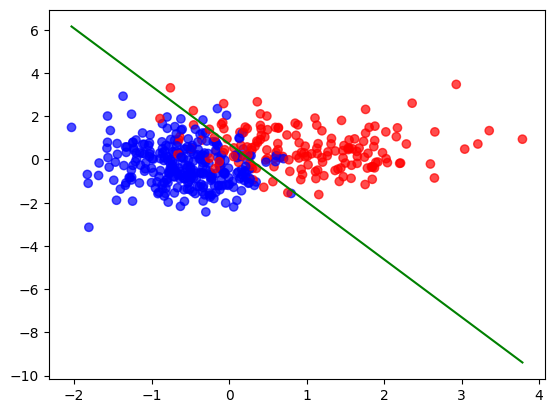

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class SVM:
    def __init__(self, X, Y, learning_rate=0.01, lambda_param=1, epochs=1000):
        self.X = X
        self.y = Y.reshape(-1, 1)
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.epochs = epochs

        self.m, self.n = X.shape
        self.w = np.zeros((self.n, 1))
        self.b = 0

    def gradient(self):

        condition = self.y * (self.X @ self.w + self.b) < 1

        dw = 2 * self.lambda_param * self.w
        db = 0

        if np.any(condition):
            dw -= self.X[condition.flatten()].T @ self.y[condition.flatten()]
            db -= np.sum(self.y[condition])

        dw /= self.m
        db /= self.m

        return dw, db

    def fit(self):
        for _ in range(self.epochs):
            dw, db = self.gradient()
            self.w -= self.lr * dw
            self.b -= self.lr * db

        return self.w, self.b

    def predict(self, X):
        return np.sign(X @ self.w + self.b)



# -----------------------------------------
df = pd.read_csv("/content/breast-cancer.csv")

train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

X = train_df[['radius_mean','smoothness_mean']].values  #df['cholesterol_total']
Y = train_df['diagnosis'].values


Y = np.where(Y == 'M', -1, 1)

X = (X - X.mean(axis=0)) / X.std(axis=0) # Z-score normalization

#----------------------
# Train SVM
svm = SVM(X, Y, learning_rate=0.1, lambda_param=1, epochs=1000)
final_w, final_b = svm.fit()

print("Final W:\n", final_w)
print("Final b:", final_b)
# -----------------------

x1 = X[:, 0]
x2 = X[:, 1]

colors = ['red' if val == -1 else 'blue' for val in Y]

x1_vals = np.linspace(min(x1),max(x1), 100)
x2_vals = (-(final_w[0][0] * x1_vals) - final_b ) / final_w[1][0]

plt.scatter(x1, x2, c=colors, alpha=0.7)
plt.plot(x1_vals,x2_vals, label= 'Regression Line', color= 'green')

plt.show()


In [20]:
def calculate_accuracy(predicted_arr, true_arr):
    if len(predicted_arr) != len(true_arr):
        raise ValueError("Arrays must have the same length to calculate accuracy.")

    correct_matches = 0
    for i in range(len(predicted_arr)):
        if predicted_arr[i] == true_arr[i]:
            correct_matches += 1

    total_items = len(predicted_arr)
    if total_items == 0:
        return 0.0

    return (correct_matches / total_items) * 100 # Returns percentage




In [23]:
test_X = test_df[['radius_mean','smoothness_mean']].values  #df['cholesterol_total']
svm_model_preds = svm.predict(test_X)


test_Y = test_df['diagnosis'].values
test_Y = np.where(test_Y == 'M', -1, 1)


print(calculate_accuracy(svm_model_preds,test_Y))





41.228070175438596
